# Notebook 14: Spotify API Integration Layer & Architecture Demo

> **Project**: Music, Brain & Wellbeing Intelligence System  
> **Phase**: Phase 3 — Spotify API Integration Layer

---

## Overview
This notebook demonstrates the end-to-end implementation of the **Spotify API Integration Layer**:
1. **OAuth 2.0 & Credentials**: Secure environment variable configuration (`SPOTIFY_CLIENT_ID`, `SPOTIFY_CLIENT_SECRET`).
2. **Mock API Response Ingestion**: Demonstrating offline data ingestion via realistic Spotify Web API `/v1/me/player/recently-played` payloads.
3. **Data Mapping & Adapter Pattern**: Mapping nested Spotify JSON into our internal DataFrame schema (`event_id`, `user_id`, `track_id`, `played_at`, `data_type="real"`, `source="spotify_api"`).
4. **Audio Feature Enrichment**: Integrating `AudioFeatureProvider` fallback adapter.
5. **End-to-End Pipeline**: Feeding mapped Spotify streams into Phase 1 Music Intelligence (`sessions.py`, `temporal.py`, `user_profile.py`) and passing derived user profiles into Phase 2 Recommendation Engine (`recommend_tracks`).
6. **API Limitations & Future Architecture**: Documenting API constraints and future placement of PostgreSQL, RAG, LLMs, FastAPI, and UI.

---


### 1. Setup Environment & Import Spotify Integration Package

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Ensure project root is in sys.path
sys.path.insert(0, os.path.abspath(".."))

from src.data.music_loader import load_music_catalog
from src.spotify.spotify_auth import SpotifyAuth
from src.spotify.spotify_client import SpotifyClient
from src.spotify.spotify_mapper import map_recently_played_to_internal, AudioFeatureProvider
from src.spotify.spotify_pipeline import run_spotify_pipeline, generate_mock_spotify_recently_played

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
os.makedirs("../docs/figures", exist_ok=True)
print("Spotify Integration package imported successfully.")


Spotify Integration package imported successfully.


### 2. Demonstrate OAuth 2.0 Authorization Flow Setup

In [2]:
auth = SpotifyAuth(
    client_id="demo_client_id_placeholder",
    client_secret="demo_client_secret_placeholder",
    redirect_uri="http://127.0.0.1:8888/callback"
)

auth_url = auth.get_authorization_url(scope="user-read-recently-played user-read-currently-playing")
print("=== Generated OAuth 2.0 Authorization URL ===")
print(auth_url)


=== Generated OAuth 2.0 Authorization URL ===
https://accounts.spotify.com/authorize?client_id=demo_client_id_placeholder&response_type=code&redirect_uri=http%3A%2F%2F127.0.0.1%3A8888%2Fcallback&scope=user-read-recently-played+user-read-currently-playing&show_dialog=true


### 3. Ingest & Map Raw Spotify API JSON Payload

In [3]:
catalog_path = "../data/raw/spotify/tracks.csv"
catalog_df = load_music_catalog(catalog_path)

# Generate realistic Spotify API GET /v1/me/player/recently-played JSON response payload
raw_spotify_json = generate_mock_spotify_recently_played(catalog_df, n_tracks=15)

print("=== Sample Raw Spotify API Payload (First Item) ===")
print(json.dumps(raw_spotify_json["items"][0], indent=2))

# Map external Spotify JSON to internal application DataFrame schema
mapped_df = map_recently_played_to_internal(
    raw_spotify_json,
    user_id="USR_SPOTIFY_LIVE_DEMO",
    source="spotify_api",
    data_type="real"
)

print("\n=== Mapped Internal History DataFrame (First 5 Rows) ===")
mapped_df[["event_id", "user_id", "track_id", "played_at", "track_name", "artist_name", "source", "data_type"]].head()


=== Sample Raw Spotify API Payload (First Item) ===
{
  "track": {
    "id": "TRK0001",
    "name": "Track 1",
    "artists": [
      {
        "name": "Artist 1"
      }
    ],
    "album": {
      "name": "Album 1"
    },
    "duration_ms": 200818
  },
  "played_at": "2026-08-27T08:00:00+00:00"
}

=== Mapped Internal History DataFrame (First 5 Rows) ===


,event_id,user_id,track_id,played_at,track_name,artist_name,source,data_type
0,EVT_SP_0001,USR_SPOTIFY_LIVE_DEMO,TRK0001,2026-08-27 08:00:00+00:00,Track 1,Artist 1,spotify_api,real
1,EVT_SP_0002,USR_SPOTIFY_LIVE_DEMO,TRK0002,2026-08-27 08:12:00+00:00,Track 2,Artist 2,spotify_api,real
2,EVT_SP_0003,USR_SPOTIFY_LIVE_DEMO,TRK0003,2026-08-27 08:24:00+00:00,Track 3,Artist 3,spotify_api,real
3,EVT_SP_0004,USR_SPOTIFY_LIVE_DEMO,TRK0004,2026-08-27 08:36:00+00:00,Track 4,Artist 4,spotify_api,real
4,EVT_SP_0005,USR_SPOTIFY_LIVE_DEMO,TRK0005,2026-08-27 08:48:00+00:00,Track 5,Artist 5,spotify_api,real


### 4. Enrich Mapped Stream History with Audio Descriptors

In [4]:
enriched_df = AudioFeatureProvider.enrich_tracks_with_features(mapped_df, catalog_df)
print("Enriched Stream History Shape:", enriched_df.shape)
print("Enriched Audio Features Present:", [c for c in ["energy", "valence", "danceability", "acousticness", "instrumentalness", "tempo"] if c in enriched_df.columns])
enriched_df[["track_id", "track_name", "energy", "valence", "danceability", "acousticness", "tempo"]].head()


Enriched Stream History Shape: (15, 19)
Enriched Audio Features Present: ['energy', 'valence', 'danceability', 'acousticness', 'instrumentalness', 'tempo']


,track_id,track_name,energy,valence,danceability,acousticness,tempo
0,TRK0001,Track 1,0.9072,0.3549,0.2811,0.1038,139.13
1,TRK0002,Track 2,0.9127,0.7221,0.7443,0.0200,116.36
2,TRK0003,Track 3,0.9195,0.6964,0.7451,0.0661,121.28
3,TRK0004,Track 4,0.6985,0.7366,0.6457,0.2480,128.15
4,TRK0005,Track 5,0.8639,0.2897,0.5195,0.0347,156.53


### 5. Execute End-to-End Integration Pipeline (Phase 1 + Phase 2)

In [5]:
history_df, user_profile, recommendations = run_spotify_pipeline(
    mode="DEMO",
    catalog_path=catalog_path,
    mock_response=raw_spotify_json,
    top_n_recs=5
)

print("=== Derived User Profile Summary ===")
print(json.dumps({
    "user_id": user_profile["user_id"],
    "total_tracks": user_profile["total_tracks_listened"],
    "total_sessions": user_profile["total_sessions"],
    "audio_summary": user_profile["audio_feature_summary"],
    "cluster_shares": user_profile["cluster_distribution"]
}, indent=2))

print("\n=== Top 5 Generated Recommendations ===")
recommendations[["track_id", "track_name", "artist_name", "genre", "similarity_score", "profile_score", "final_score", "recommendation_reason"]]


=== Derived User Profile Summary ===
{
  "user_id": "USR_SPOTIFY_001",
  "total_tracks": 15,
  "total_sessions": 1,
  "audio_summary": {
    "energy_mean": 0.7389,
    "energy_std": 0.2223,
    "valence_mean": 0.502,
    "valence_std": 0.167,
    "danceability_mean": 0.6247,
    "danceability_std": 0.193,
    "acousticness_mean": 0.2675,
    "acousticness_std": 0.2925,
    "instrumentalness_mean": 0.4267,
    "instrumentalness_std": 0.268,
    "tempo_mean": 125.0347,
    "tempo_std": 25.2193
  },
  "cluster_shares": {
    "cluster_0": 0.5333,
    "cluster_2": 0.2667,
    "cluster_1": 0.1333,
    "cluster_3": 0.0667
  }
}

=== Top 5 Generated Recommendations ===


,track_id,track_name,artist_name,genre,similarity_score,profile_score,final_score,recommendation_reason
0,TRK0031,Track 31,Artist 31,Synthwave,0.6177,0.5333,0.5924,Recommended Synthwave track with high energy a...
1,TRK0400,Track 400,Artist 50,Electronic,0.6084,0.5333,0.5859,Recommended Electronic track with high energy ...
2,TRK0070,Track 70,Artist 20,Synthwave,0.5965,0.5333,0.5775,Recommended Synthwave track with high energy a...
3,TRK0078,Track 78,Artist 28,Synthwave,0.5835,0.5333,0.5684,Recommended Synthwave track with high energy a...
4,TRK0074,Track 74,Artist 24,Rock,0.5126,0.2667,0.4388,Recommended Rock track with high energy acoust...


### 6. Pipeline Summary Visualizations

C:\Users\aksha\AppData\Local\Temp\ipykernel_15820\2782624530.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[k.replace("_mean", "") for k in feature_keys], y=feature_vals, palette="viridis", ax=ax1)


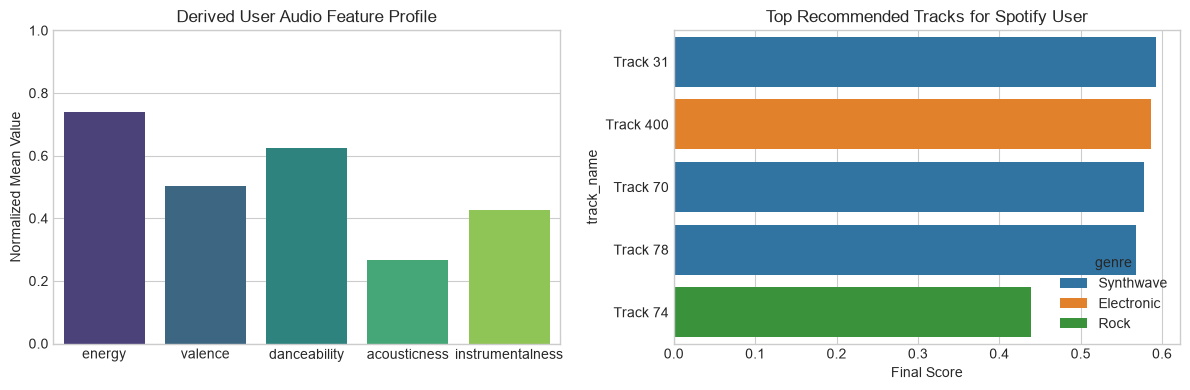

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: User Feature Profile Radar/Bar Comparison
feature_keys = ["energy_mean", "valence_mean", "danceability_mean", "acousticness_mean", "instrumentalness_mean"]
feature_vals = [user_profile["audio_feature_summary"][k] for k in feature_keys]

sns.barplot(x=[k.replace("_mean", "") for k in feature_keys], y=feature_vals, palette="viridis", ax=ax1)
ax1.set_title("Derived User Audio Feature Profile")
ax1.set_ylim(0, 1.0)
ax1.set_ylabel("Normalized Mean Value")

# Plot 2: Top Recommendations Final Scores
sns.barplot(data=recommendations, y="track_name", x="final_score", hue="genre", dodge=False, ax=ax2)
ax2.set_title("Top Recommended Tracks for Spotify User")
ax2.set_xlabel("Final Score")

plt.tight_layout()
plt.savefig("../docs/figures/14_spotify_pipeline_summary.png", dpi=300)
plt.show()


## Technical Discussion: API Constraints & Target System Architecture

### 1. Spotify API Constraints
- **Recent Window Constraint**: GET `/v1/me/player/recently-played` retrieves only up to 50 recent play events ($pprox$ 2–3 days of active listening). It is an **observed listening window**, not an unlimited lifetime archive.
- **Developer Access Policies**: Spotify API access policies restrict automated bulk audio-features endpoints for non-extended commercial developer apps. The `AudioFeatureProvider` adapter safely isolates this boundary.

### 2. Future Production Architecture
```text
Spotify Web API (External Data Source)
    ↓
FastAPI Backend (POST /auth/callback, GET /user/profile, POST /recommend)
    ↓
PostgreSQL Database (Persistent User Memory & Event Storage)
    ↓
Phase 1 Feature Engineering Pipeline (Sessions, Temporal Encodings, User Profiles)
    ↓
Phase 2 Content-Based Recommendation Engine
    ↓
Phase 3 Vector Database / Research RAG Layer (Music Therapy Literature Retrieval)
    ↓
Phase 4 Non-Clinical LLM Explanation Layer
    ↓
Interactive Web Dashboard / Frontend
```
